In [1]:
!pip install matplotlib seaborn -q

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, max as max_, min as min_, count, sum as sum_, datediff, to_date, lit
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

from mpl_toolkits.mplot3d import Axes3D

In [4]:
spark = SparkSession.builder \
    .appName("olist_ml") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/10 17:16:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Customer Segmentation

## Load data from Hadoop

In [5]:
orders_path = "hdfs://namenode:9000/bigdata/olist_orders_dataset.csv"
payments_path = "hdfs://namenode:9000/bigdata/olist_order_payments_dataset.csv"
customers_path = "hdfs://namenode:9000/bigdata/olist_customers_dataset.csv"

In [6]:
orders_df = spark.read.csv(orders_path, header=True, inferSchema=True)
payments_df = spark.read.csv(payments_path, header=True, inferSchema=True)
customers_df = spark.read.csv(customers_path, header=True, inferSchema=True)

In [7]:
orders_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [8]:
payments_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)



In [9]:
customers_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)



## Tính toán chỉ số RFM

### Kết hợp các bảng dữ liệu

In [10]:
# Lấy các cột cần thiết từ bảng Orders và ép kiểu ngày tháng
orders_clean = orders_df.select(
    "order_id", 
    "customer_id", 
    to_date(col("order_purchase_timestamp")).alias("purchase_date")
).filter(col("order_status") == "delivered")

In [11]:
# Lấy tổng số tiền của mỗi đơn hàng từ bảng Payments
payments_clean = payments_df.groupBy("order_id").agg(sum_("payment_value").alias("order_value"))

In [12]:
# Kết hợp với bảng Customers để lấy customer_unique_id
joined_df = orders_clean.join(payments_clean, "order_id", "inner") \
                        .join(customers_df.select("customer_id", "customer_unique_id"), "customer_id", "inner")

### Xác định ngày mốc để tính Recency

In [13]:
max_date_row = joined_df.select(max_("purchase_date")).collect()
latest_date = max_date_row[0][0]

### Tính toán R, F, M cho từng khách hàng

In [14]:
rfm_df = joined_df.groupBy("customer_unique_id").agg(
    datediff(lit(latest_date), max_("purchase_date")).alias("Recency"),
    count("order_id").alias("Frequency"),
    sum_("order_value").alias("Monetary")
)

In [15]:
rfm_df.show(5)

[Stage 17:===========================================>              (3 + 1) / 4]

+--------------------+-------+---------+------------------+
|  customer_unique_id|Recency|Frequency|          Monetary|
+--------------------+-------+---------+------------------+
|969cdc8af5b070747...|    114|        1|            134.66|
|f2a9bc9a1db05c873...|     29|        1|            122.42|
|d0c5e56e04e886e73...|    417|        1|             79.24|
|5f03b965e26e79a37...|    435|        1|              54.0|
|14a188558af6cd5bc...|    175|        2|245.14999999999998|
+--------------------+-------+---------+------------------+
only showing top 5 rows



## Tiền xử lý dữ liệu

In [16]:
# Gom các cột R, F, M thành một vector duy nhất đặt tên là "features"
assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"], 
    outputCol="features"
)
features_df = assembler.transform(rfm_df)

In [17]:
# Chuẩn hóa dữ liệu bằng StandardScaler (đưa về phân phối chuẩn có mean=0, std=1)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(features_df)
scaled_df = scaler_model.transform(features_df)

In [18]:
scaled_df.select("customer_unique_id", "scaledFeatures").show(5, truncate=False)

[Stage 34:===========================================>              (3 + 1) / 4]

+--------------------------------+---------------------------------------------------------------+
|customer_unique_id              |scaledFeatures                                                 |
+--------------------------------+---------------------------------------------------------------+
|969cdc8af5b07074766e79c1e6d76c24|[-0.8091975525366429,-0.15982942057401126,-0.1349394824725525] |
|f2a9bc9a1db05c873e1419654f747f9e|[-1.3662533910553236,-0.15982942057401126,-0.18902349273605534]|
|d0c5e56e04e886e73c79b3b71f0d6f0b|[1.1765426718299483,-0.15982942057401126,-0.3798198622767461]  |
|5f03b965e26e79a371d229cfeeb578d7|[1.2945074376339043,-0.15982942057401126,-0.4913460403037732]  |
|14a188558af6cd5bc222ca773d395a7f|[-0.40942806842323676,4.622604943698428,0.35327475723450885]   |
+--------------------------------+---------------------------------------------------------------+
only showing top 5 rows



## Tìm số lượng cụm (K) tối ưu

In [19]:
wcss = []

evaluator = ClusteringEvaluator(featuresCol='scaledFeatures', metricName='silhouette')

In [20]:
for k in range(2, 9):
    kmeans = KMeans(featuresCol='scaledFeatures', k=k, seed=42)
    model = kmeans.fit(scaled_df)
    
    wcss_val = model.summary.trainingCost
    wcss.append(wcss_val)
    print(f"Với K = {k}, WCSS = {wcss_val}")

26/06/10 17:17:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Với K = 2, WCSS = 214246.43307788315
Với K = 3, WCSS = 137738.1380100655
Với K = 4, WCSS = 92095.62772316125
Với K = 5, WCSS = 77879.42991813897
Với K = 6, WCSS = 68385.43627424326
Với K = 7, WCSS = 54110.90188078984
Với K = 8, WCSS = 50982.268260384415


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


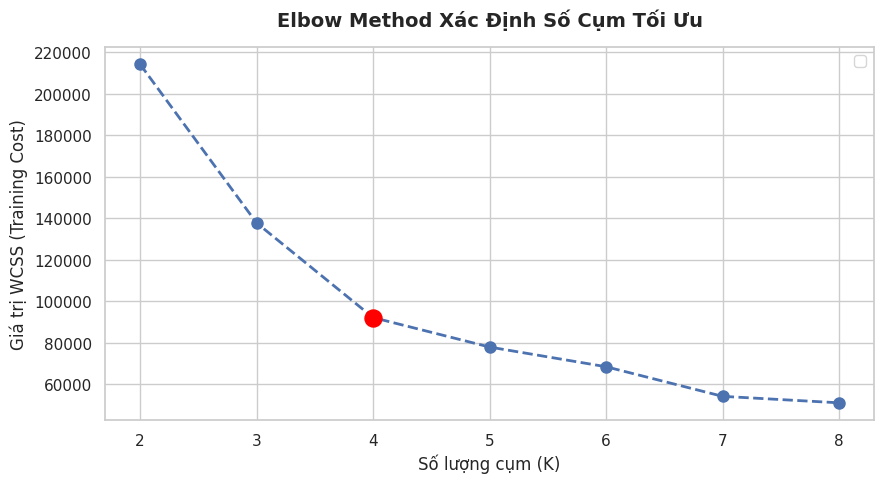

In [27]:
k_range = range(2, 9)

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")  # Tạo nền lưới màu trắng sang trọng

# Vẽ đường line đứt nét và các điểm nút tròn
plt.plot(list(k_range), wcss, marker='o', linestyle='--', color='b', linewidth=2, markersize=8)

# Vẽ một điểm tròn đỏ to hơn tại tọa độ K=4 để làm nổi bật
plt.scatter(4, wcss[2], color='red', s=150, zorder=5) 

# Cấu hình tiêu đề và nhãn hiển thị (Font tiếng Việt chuẩn cho báo cáo)
plt.title('Elbow Method Xác Định Số Cụm Tối Ưu', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng cụm (K)', fontsize=12)
plt.ylabel('Giá trị WCSS (Training Cost)', fontsize=12)
plt.xticks(list(k_range))  # Đảm bảo trục X hiển thị rõ từng số từ 2 đến 8
plt.legend(fontsize=11)

# Tối ưu hóa khoảng trống và lưu thành file ảnh chất lượng cao (.png)
plt.tight_layout()
plt.savefig('elbow_method_pyspark.png', dpi=300)
plt.show()

## Huấn luyện mô hình K-Means với K tối ưu

In [21]:
# Cấu hình và chạy K-Means với K=4
optimal_k = 4
kmeans = KMeans(featuresCol='scaledFeatures', predictionCol='Cluster', k=optimal_k, seed=42)
model = kmeans.fit(scaled_df)

# Gán nhãn cụm (Cluster) cho từng khách hàng
result_df = model.transform(scaled_df)
result_df.select("customer_unique_id", "Recency", "Frequency", "Monetary", "Cluster").show(5)

[Stage 807:==========================================>              (3 + 1) / 4]

+--------------------+-------+---------+------------------+-------+
|  customer_unique_id|Recency|Frequency|          Monetary|Cluster|
+--------------------+-------+---------+------------------+-------+
|969cdc8af5b070747...|    114|        1|            134.66|      0|
|f2a9bc9a1db05c873...|     29|        1|            122.42|      0|
|d0c5e56e04e886e73...|    417|        1|             79.24|      1|
|5f03b965e26e79a37...|    435|        1|              54.0|      1|
|14a188558af6cd5bc...|    175|        2|245.14999999999998|      3|
+--------------------+-------+---------+------------------+-------+
only showing top 5 rows



In [22]:
evaluator = ClusteringEvaluator(predictionCol="Cluster", featuresCol="scaledFeatures", metricName="silhouette", distanceMeasure="squaredEuclidean")
silhouette = evaluator.evaluate(result_df)
print(f"Silhouette with squared euclidean distance = {silhouette}")

[Stage 824:==============>                                          (1 + 3) / 4]

Silhouette with squared euclidean distance = 0.6533346026072333


In [23]:
# Thống kê giá trị trung bình của từng cụm
analysis_df = result_df.groupBy("Cluster").agg(
    count("customer_unique_id").alias("Total_Customers"),
    sum_("Monetary").alias("Total_Revenue"),
    min_("Recency").alias("Min_Recency"),
    max_("Recency").alias("Max_Recency"),
    count("Frequency").alias("Count_Check") # Để kiểm tra tính đúng đắn
)

# Tính chi tiết trung bình R, F, M
final_summary = result_df.groupBy("Cluster").mean("Recency", "Frequency", "Monetary")
final_summary.show()

+-------+------------------+------------------+------------------+
|Cluster|      avg(Recency)|    avg(Frequency)|     avg(Monetary)|
+-------+------------------+------------------+------------------+
|      1| 387.2113710409657|               1.0| 133.4853017678796|
|      3| 219.9592352092352|2.1143578643578644|289.68025252525234|
|      2|239.00536968194962|1.0128046261875259|1160.2636679058241|
|      0| 127.8040143538783|               1.0|134.31087897787756|
+-------+------------------+------------------+------------------+



In [24]:
analysis_df.show()

+-------+---------------+------------------+-----------+-----------+-----------+
|Cluster|Total_Customers|     Total_Revenue|Min_Recency|Max_Recency|Count_Check|
+-------+---------------+------------------+-----------+-----------+-----------+
|      1|          37446|  4998490.61000002|        258|        695|      37446|
|      3|           2772| 802993.6599999995|          1|        691|       2772|
|      2|           2421|2808998.3400000003|          1|        694|       2421|
|      0|          50718| 6811979.159999995|          0|        258|      50718|
+-------+---------------+------------------+-----------+-----------+-----------+



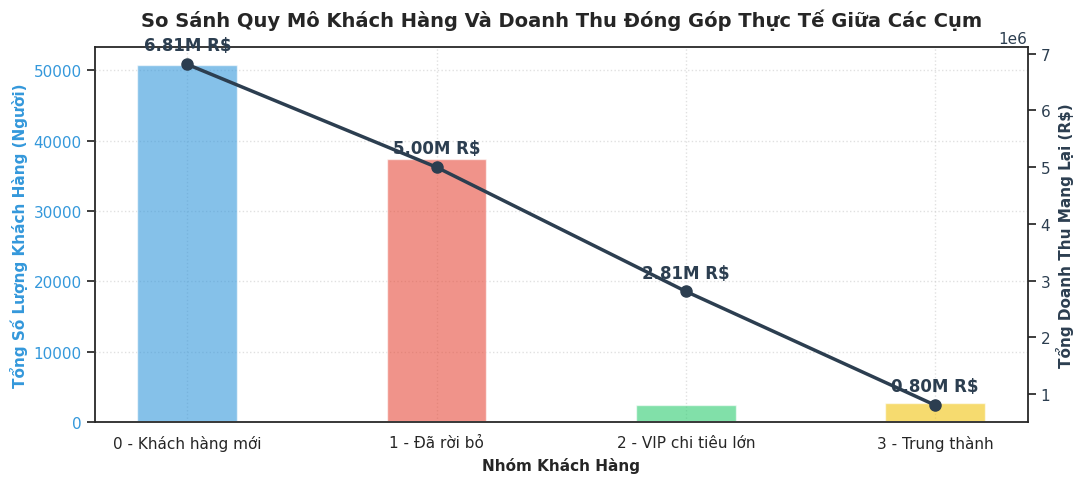

In [29]:
summary_df = result_df.groupBy("Cluster").agg(
    F.count("customer_unique_id").alias("Total_Customers"),
    F.sum("Monetary").alias("Total_Revenue")
).sort("Cluster").toPandas()

# Ánh xạ nhãn tiếng Việt cho các cụm
cluster_labels = {
    0: "0 - Khách hàng mới",
    1: "1 - Đã rời bỏ",
    2: "2 - VIP chi tiêu lớn",
    3: "3 - Trung thành"
}
summary_df['Cluster_Name'] = summary_df['Cluster'].map(cluster_labels)

fig, ax1 = plt.subplots(figsize=(11, 5))
sns.set_theme(style="white")

# Trục Y thứ nhất (Bên trái): Vẽ cột biểu thị Số lượng khách hàng
ax1.bar(summary_df['Cluster_Name'], summary_df['Total_Customers'], color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'], alpha=0.6, width=0.4)
ax1.set_xlabel('Nhóm Khách Hàng', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tổng Số Lượng Khách Hàng (Người)', color='#3498db', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.grid(True, linestyle=':', alpha=0.6)

# Trục Y thứ hai (Bên phải): Vẽ đường biểu thị Tổng doanh thu mang lại
ax2 = ax1.twinx()
ax2.plot(summary_df['Cluster_Name'], summary_df['Total_Revenue'], color='#2c3e50', marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Tổng Doanh Thu Mang Lại (R$)', color='#2c3e50', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2c3e50')

# Tự động ghi nhãn số triệu R$ (Triệu Real) lên đỉnh các nút thắt của đường doanh thu
for i, txt in enumerate(summary_df['Total_Revenue']):
    ax2.annotate(f"{txt/1e6:.2f}M R$", (summary_df['Cluster_Name'][i], summary_df['Total_Revenue'][i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#2c3e50')

plt.title('So Sánh Quy Mô Khách Hàng Và Doanh Thu Đóng Góp Thực Tế Giữa Các Cụm', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('customer_vs_revenue_actual.png', dpi=300)
plt.show()

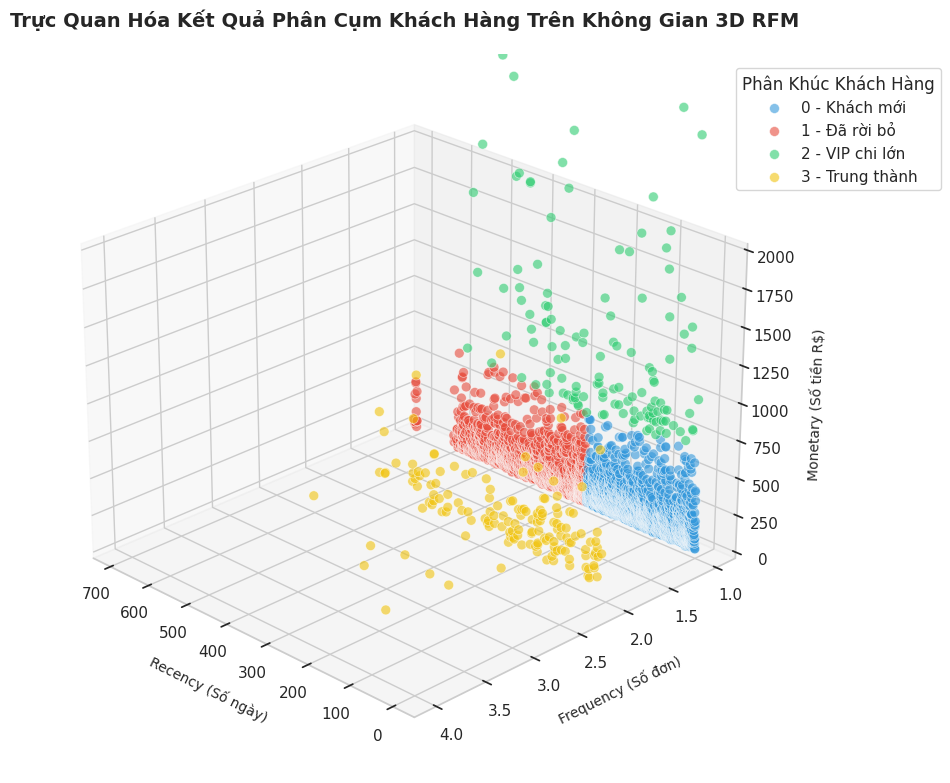

In [41]:
sampled_df = result_df.select("Cluster", "Recency", "Frequency", "Monetary") \
                       .sample(withReplacement=False, fraction=0.05, seed=42) \
                       .toPandas()

# Ánh xạ tên cụm tiếng Việt
cluster_labels = {
    0: "0 - Khách mới",
    1: "1 - Đã rời bỏ",
    2: "2 - VIP chi lớn",
    3: "3 - Trung thành"
}
sampled_df['Segment'] = sampled_df['Cluster'].map(cluster_labels)

# 2. Khởi tạo không gian vẽ 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Bảng màu phân biệt rõ ràng cho 4 cụm
colors = {
    "0 - Khách mới": "#3498db",      # Xanh dương
    "1 - Đã rời bỏ": "#e74c3c",      # Đỏ
    "2 - VIP chi lớn": "#2ecc71",    # Xanh lá
    "3 - Trung thành": "#f1c40f"     # Vàng
}

# 3. Vẽ từng cụm dữ liệu lên không gian 3D
for segment, group in sampled_df.groupby('Segment'):
    ax.scatter(
        group['Recency'], 
        group['Frequency'], 
        group['Monetary'], 
        label=segment,
        c=colors[segment],
        s=50,          # Kích thước chấm dữ liệu
        alpha=0.6,     # Độ trong suốt để nhìn xuyên qua các cụm
        edgecolors='w',
        linewidth=0.5
    )

# 4. Cấu hình tiêu đề và trục tọa độ
ax.set_title('Trực Quan Hóa Kết Quả Phân Cụm Khách Hàng Trên Không Gian 3D RFM', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Recency (Số ngày)', fontsize=10, labelpad=10)
ax.set_ylabel('Frequency (Số đơn)', fontsize=10, labelpad=10)
ax.set_zlabel('Monetary (Số tiền R$)', fontsize=10, labelpad=10)

ax.set_zlim(0, 2000)

# Thay đổi góc nhìn (elevation và azimuthal) để thấy rõ khoảng hở giữa các cụm
ax.view_init(elev=25, azim=135)

ax.legend(title="Phân Khúc Khách Hàng", loc='lower left', bbox_to_anchor=(0.95, 0.8), fontsize=11)
plt.tight_layout()
plt.show()